# 01 · Verificação do RTL

A verificação foi construída em camadas, cada uma cobrindo um tipo diferente de
risco (seção 7 do Plano Mestre):

1. **Testes unitários** — cada bloco isolado (ALU, regfile, LSU, multiplicador...).
2. **Testes dirigidos por instrução** — as 44 instruções fechadas, executadas no SoC,
   com scoreboard no banco de registradores. Foram eles que encontraram os
   **dois bugs reais de PC em JAL/JALR** (`docs/governance/DECISIONS.md`, ADR-003).
3. **Firmware** compilado com o GCC RISC-V real.
4. **Teste diferencial randomizado** — programas aleatórios executados no RTL e num
   **modelo de referência independente** (`tools/iss/rv32_iss.py`, escrito a partir
   da especificação RISC-V, não do RTL). Qualquer diferença na memória é um bug.
5. **Teste de mutação** — injeta bugs realistas no RTL e mede se a bateria os pega.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))          # notebooks/_common.py
from _common import ROOT, run, py, summary, style, SERIES
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import SVG, Image, Markdown, display
print("projeto:", ROOT.name)

projeto: ChampionCHIP (Terminar)


## Regressão

In [2]:
run("bash scripts/run_regression.sh", tail=25)
pd.read_csv(ROOT / "reports/regression_summary.csv")

==== 1. TESTES UNITARIOS ====
PASS  unit/tb_alu
PASS  unit/tb_regfile
PASS  unit/tb_imm_gen
PASS  unit/tb_branch_cmp
PASS  unit/tb_mult_unit
PASS  unit/tb_lsu
PASS  unit/tb_address_decoder
PASS  unit/tb_crc_unit
==== 2. TESTES DE ISA (dirigidos por instrucao) ====
PASS  isa/tb_isa_alu
PASS  isa/tb_isa_mem_upper_sys
PASS  isa/tb_isa_branch_jump
PASS  isa/tb_isa_zmmul
==== 3. FIRMWARE (GCC RISC-V -> ELF -> hex -> simulacao) ====
PASS  firmware/smoke_test
==== 4. DIFERENCIAL RANDOMIZADO vs modelo de referencia (20 x 200 instr.) ====
cobertura do corpo aleatorio: 40 instrucoes distintas, 3644 execucoes
random: 20/20 programas identicos ao modelo de referencia
PASS  random/diferencial (20/20)
==== RESULTADO: TUDO PASSOU ====
[exit code 0]


,suite,teste,status
0,unit,tb_alu,PASS
1,unit,tb_regfile,PASS
2,unit,tb_imm_gen,PASS
3,unit,tb_branch_cmp,PASS
4,unit,tb_mult_unit,PASS
5,unit,tb_lsu,PASS
6,unit,tb_address_decoder,PASS
7,unit,tb_crc_unit,PASS
8,isa,tb_isa_alu,PASS
9,isa,tb_isa_mem_upper_sys,PASS


## O modelo de referência (ISS)

O mesmo programa roda no modelo em Python. Abaixo, o firmware de smoke-test
executado no ISS: os registradores finais são o "gabarito" independente.

In [3]:
sys.path.insert(0, str(ROOT / "tools/iss"))
from rv32_iss import RV32ISS, load_hex
iss = RV32ISS(load_hex(ROOT / "firmware/build/smoke_test.hex")).run()
print(f"EBREAK apos {iss.steps} instrucoes, pc final = 0x{iss.pc:08x}")
print("assinatura na DMEM:", hex(iss.dmem_words(10)[8]), "(0x600dc0de = PASS)")
pd.DataFrame(sorted(iss.histogram.items(), key=lambda kv: -kv[1]), columns=["instrucao", "execucoes"]).head(12)

EBREAK apos 91 instrucoes, pc final = 0x00400190
assinatura na DMEM: 0x600dc0de (0x600dc0de = PASS)


,instrucao,execucoes
0,ADDI,39
1,BNE,17
2,LUI,6
3,AUIPC,3
4,SW,3
5,JAL,3
6,BEQ,2
7,ADD,1
8,SUB,1
9,OR,1


## Cobertura do teste randomizado

Execuções por instrução no **corpo aleatório** dos programas (sem o prólogo e
o epílogo fixos). JALR, FENCE e ECALL ficam de fora do gerador e são cobertos
pelos testes dirigidos.

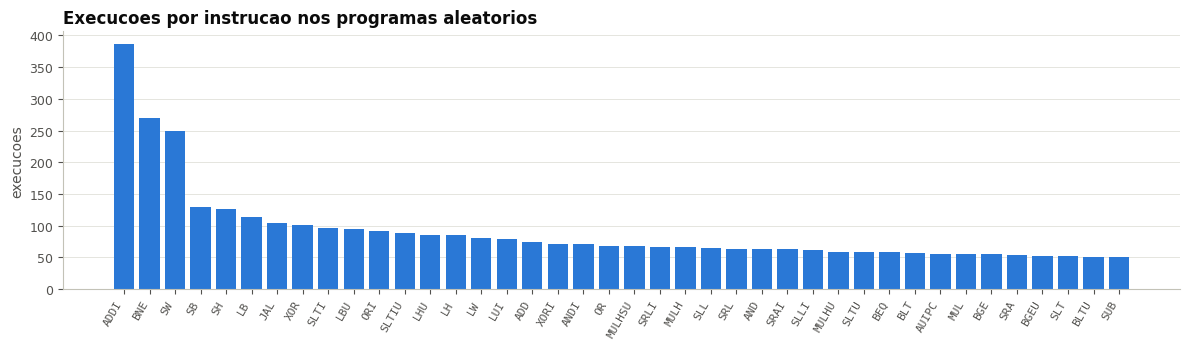

In [4]:
cov = pd.read_csv(ROOT / "docs/evidence/isa/random_coverage.csv").sort_values("execucoes", ascending=False)
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.bar(cov["instrucao"], cov["execucoes"], color=SERIES[0], width=0.8)
style(ax, "Execucoes por instrucao nos programas aleatorios", ylabel="execucoes")
ax.grid(axis="x", visible=False)
plt.xticks(rotation=60, ha="right", fontsize=8, family="monospace")
plt.tight_layout(); plt.show()

## Teste de mutação

Cada linha é um bug realista injetado no RTL. A barra mostra em quantos dos 20
programas aleatórios o bug foi detectado — basta um para "matar" o mutante.

Duas lacunas **no próprio gerador de testes** foram encontradas assim e corrigidas
(ver `versioning/HISTORICO.md`): o bit 11 do imediato de branch nunca era exercitado
(só havia saltos curtos para frente) e os loads quase sempre liam zero.

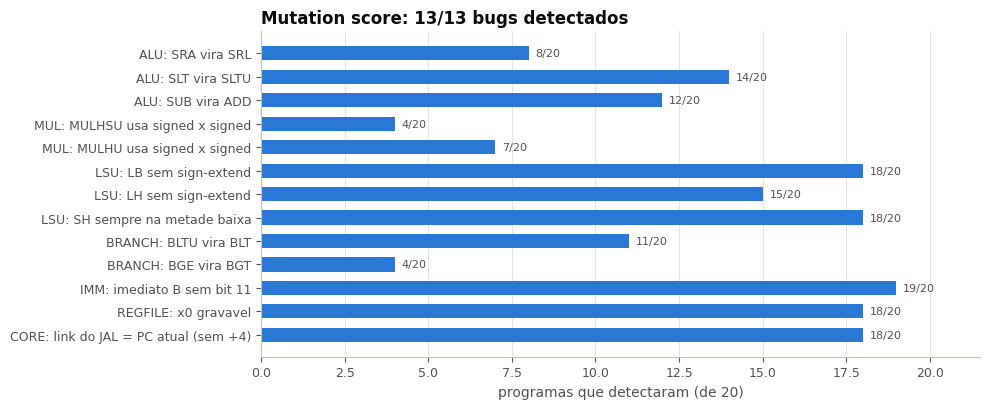

In [5]:
mut = pd.read_csv(ROOT / "reports/mutation.csv")
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(mut["mutante"][::-1], mut["programas_que_detectaram"][::-1], color=SERIES[0], height=0.6)
for i, v in enumerate(mut["programas_que_detectaram"][::-1]):
    ax.text(v + 0.2, i, f"{v}/20", va="center", fontsize=8, color="#52514e")
style(ax, f"Mutation score: {(mut['status'] == 'MORTO').sum()}/{len(mut)} bugs detectados", xlabel="programas que detectaram (de 20)")
ax.set_xlim(0, 21.5); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()